# Appendix A — Quantitative Toolbox (MM desk)

**Book:** Lehalle & Laruelle, *Market Microstructure in Practice* · App.A pp.248–315  
**Status:** `exp_run` · paper only · no orders  
**Out:** `research/out/appendix_quant/`

## Executive takeaway

- **HL is tick-constrained** (~99% 1-tick); **Lighter is continuous** (~15% 1-tick, mean ε≈11.5).
- **E-min schedules** on real HL ETH \(V_n\) deviate from uniform by mean L1≈**0.40**.
- **Xvenue Epps** (HL mid vs Deribit ETH): corr≈0 at ≤60s → **~0.87 at 600s**.
- Trade arrivals **cluster** (CV≫1; lag-1 ACF 0.17–0.44). Hawkes MoM \(R\) is indicative only.
- FEI: link to Ch.1 only — do not redo spatial fragmentation here.


## Theory / formulas

| § | Formula | Code |
|---|---------|------|
| A.5 | \(\varepsilon=(A-B)/\tau\), leeway \(\varepsilon-1\) | `harris_tick_features` |
| A.6 | \(v_n \propto V_n/\sigma_n^{1/\gamma}\) | `schedule_expectation_min` |
| A.6 | \(C=\mathbb{E}(W)+\lambda\mathrm{Var}(W)\) | `schedule_mean_variance_linear` |
| A.11 | \(\lambda(t)=\lambda_0+\sum \alpha e^{-\beta(t-\tau_i)}\) | `hawkes_descriptive` (MoM) |
| A.12 | \(\widehat{\mathrm{corr}}(\Delta)\) last-tick sync | `epps_correlation` |
| A.1 | \(F=H(q)/\log N\) | Ch.1 + `fei` |

**Honesty:** schedule κ/λ uncalibrated; Hawkes ≠ MLE; xasset Epps on 1m marks is coarse.


In [1]:
from pathlib import Path
import json
ROOT = Path('/home/dev/srv/ares-microstructure')
OUT = ROOT / 'research/out/appendix_quant'
payload = json.loads((OUT / 'exp_appa_summary.json').read_text())
print('created', payload['created_at'])
print('symbol', payload['symbol'], 'tob_day', payload['tob_day'])
print('warehouse_days', payload['warehouse_days'])


created 2026-09-29T22:42:43.365563+00:00
symbol ETH tob_day 20260929
warehouse_days ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-25', '2026-09-26']


## Data & method

1. Collector TOB `20260929` ETH → Harris  
2. HL trade tape DENSE days → volume curve + Hawkes  
3. Deribit 1m marks ETH/BTC → xasset Epps / signature  
4. HL `l2_rebuild` vs Deribit mark (2026-09-26) → xvenue Epps  
5. Ch.1 JSON → FEI link only  

No ClickHouse MCP.


In [2]:
import pandas as pd
h = payload['harris']['venues']
rows = []
for v, m in h.items():
    rows.append({
        'venue': v, 'tick': m['tick'], 'frac_one_tick': m['frac_one_tick'],
        'mean_eps_ticks': m['mean_spread_ticks'], 'mean_leeway': m['mean_leeway'],
        'mean_spread_bps': m['mean_spread_bps'], 'rel_tick_bps': m['mean_rel_tick_bps'], 'n': m['n'],
    })
pd.DataFrame(rows)


,venue,tick,frac_one_tick,mean_eps_ticks,mean_leeway,mean_spread_bps,rel_tick_bps,n
0,hyperliquid,0.10,0.991211,1.020345,0.020345,0.380188,0.372609,6144
1,lighter,0.01,0.151916,11.515247,10.515247,0.429252,0.037272,28858
2,risex,0.01,0.501254,18.185161,17.185161,0.677873,0.037275,10769


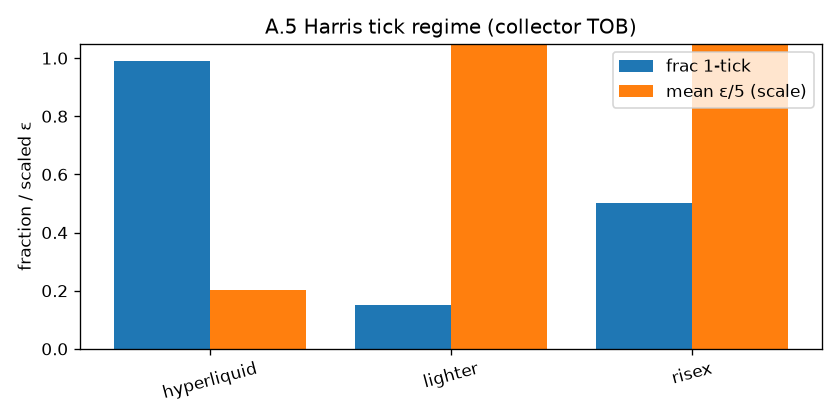

In [3]:
from IPython.display import Image, display
display(Image(filename=str(OUT / 'fig_harris_tick.png')))


## A.6 Schedule toys on real \(V_n\)

Expectation-min (Prop.1) vs uniform vs mean–var toy. σ from within-hour trade log-increments (proxy).


In [4]:
sch = payload['schedule']
sched_days = pd.DataFrame(payload['schedule_days_summary'])
print('mean L1(E-min vs uniform) =', sch['mean_l1_exp_vs_uni'])
sched_days


mean L1(E-min vs uniform) = 0.3970980931322489


,day,n_trades,peak_slot,fei_slot,l1_exp_vs_uniform,l1_mv_vs_uniform,participation_peak_exp,participation_peak_mv
0,2026-09-14,230338,20,0.928041,0.396725,0.319167,0.077306,0.066682
1,2026-09-15,266729,18,0.845130,0.292287,0.230879,0.105973,0.074065
2,2026-09-16,198274,18,0.855660,0.381612,0.299557,0.075181,0.080648
3,2026-09-25,147652,11,0.895350,0.418229,0.226734,0.116019,0.063723
4,2026-09-26,69761,15,0.931175,0.496637,0.334759,0.093677,0.081912


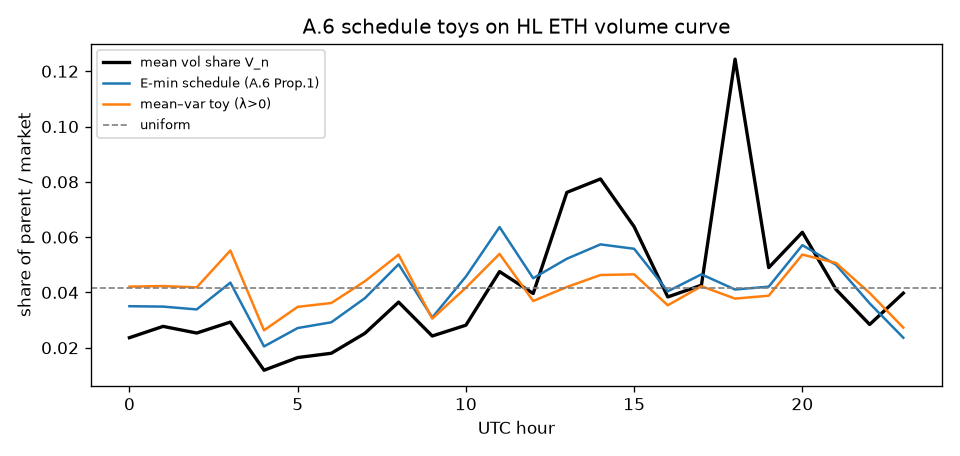

In [5]:
display(Image(filename=str(OUT / 'fig_schedule.png')))


## A.12 Epps / signature

Xasset on 1m marks shows little classic decay (already synchronous). **Xvenue** HL↔Deribit shows the textbook rise of correlation with Δ.


In [6]:
epps_xa = pd.DataFrame(payload['epps_hawkes']['epps_xasset_eth_btc_deribit'])
epps_xv = pd.DataFrame(payload['epps_hawkes']['epps_xvenue_hl_deribit_eth'])
print('xasset ETH-BTC (Deribit marks)')
display(epps_xa)
print('xvenue HL mid vs Deribit ETH mark', payload['epps_hawkes']['epps_xvenue_day'])
display(epps_xv)


xasset ETH-BTC (Deribit marks)


,delta_s,n_returns,corr,cov
0,60.0,18725,0.971106,7.253015e-07
1,120.0,9362,0.975279,1.460926e-06
2,300.0,3745,0.973755,3.690769e-06
3,600.0,1872,0.972686,7.476161e-06
4,900.0,1248,0.974710,1.134882e-05
5,1800.0,624,0.974672,2.254930e-05


xvenue HL mid vs Deribit ETH mark 2026-09-26


,delta_s,n_returns,corr,cov
0,5.0,17204,-0.001443,-8.662200e-12
1,10.0,8602,0.006026,7.536945e-11
2,15.0,5734,-0.016738,-3.186784e-10
3,30.0,2867,-0.021166,-8.561637e-10
4,60.0,1433,-0.012081,-9.876211e-10
5,120.0,716,0.345762,5.804181e-08
6,300.0,286,0.805261,3.390646e-07
7,600.0,143,0.870542,6.962465e-07


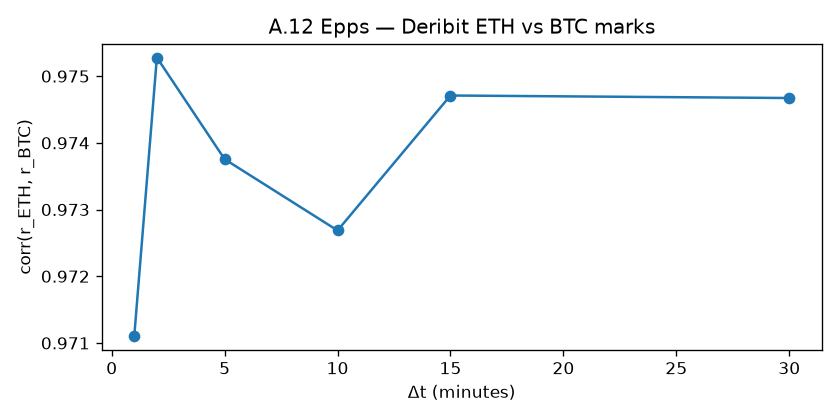

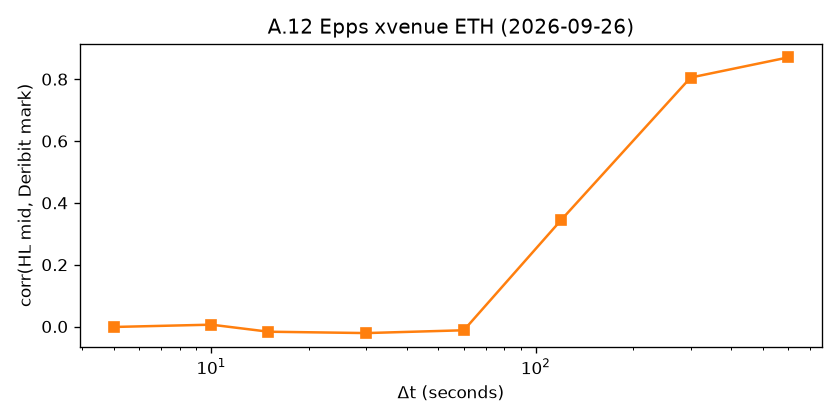

In [7]:
display(Image(filename=str(OUT / 'fig_epps_xasset.png')))
display(Image(filename=str(OUT / 'fig_epps_xvenue.png')))


## A.11 Hawkes-style clustering (descriptive)

Inter-arrival CV ≫ 1 and positive count ACF ⇒ clustering. MoM branching ratio is **Hold** (not MLE).


In [8]:
hawkes = pd.DataFrame(payload['epps_hawkes']['hawkes_hl_eth'])
hawkes['R_mom'] = hawkes['hawkes_mom'].apply(lambda x: (x or {}).get('branching_ratio'))
hawkes[['day','n_events','mean_rate_per_s','interarrival_cv','acf_lag1','acf_lag5','R_mom']]


,day,n_events,mean_rate_per_s,interarrival_cv,acf_lag1,acf_lag5,R_mom
0,2026-09-14,230338,2.678131,8.680265,0.174589,0.125691,0.698678
1,2026-09-15,266729,3.108150,2.796482,0.310958,0.237066,0.699006
2,2026-09-16,198274,2.300376,2.561044,0.246981,0.212853,0.784078
3,2026-09-25,147652,1.782354,2.441211,0.308387,0.155282,0.450428
4,2026-09-26,69761,0.807195,1.966343,0.435392,0.241160,0.536192


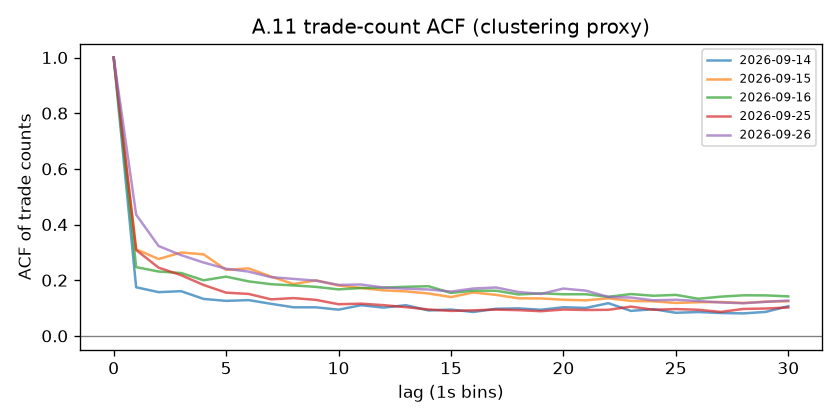

In [9]:
display(Image(filename=str(OUT / 'fig_hawkes_acf.png')))


## A.1 FEI link to Ch.1

Do not redo Ch.1. Book Table 1.2 benchmarks + Ch.1 observed FEI.


In [10]:
fei = payload['fei_link']
print('Book Table 1.2:', fei['book_table_1_2'])
print('Ch.1 FEI size / updates:', fei.get('ch01_fei_size'), fei.get('ch01_fei_updates'))
print('Ch.1 size share:', fei.get('ch01_size_share'))
print('Trade hourly FEI (temporal):', fei.get('ch01_trade_hourly_fei_mean'))
print(fei.get('honesty'))


Book Table 1.2: {'50/50': 1.0, '70/20/10': 0.7298466991620975, '70/20/5/5': 0.6283898247235197, '25/25/25/25': 1.0}
Ch.1 FEI size / updates: 0.25948491448839617 0.8199706778672756
Ch.1 size share: {'hyperliquid': 0.9089809351118127, 'lighter': 0.0349900539910132, 'risex': 0.056029010897174256}
Trade hourly FEI (temporal): 0.891903014742838
Ch.1 FEI is TOB-size / update-count; A.1 definition is market-share entropy. Trade-notional spatial FEI still Hold (see Ch.1 iterate).


## MM interpretation

| Function | Action |
|----------|--------|
| Quoting | HL: size/skew/cancel; Lit: continuous tick management |
| POV / schedule | Child weights ∝ \(V_n/\sigma_n\); avoid flat TWAP prior |
| Xvenue hedge | Sync horizon ≥ minutes (Epps) before trusting corr |
| Intensity | Elevated ACF/CV → burst gate research |
| Fragmentation | Use Ch.1 Promote list (`crossed_nbbo`, `update_share`, tick) |

## Promote / Hold / Kill

See `CANDIDATES.md`.

**Promote:** `tick.frac_one_tick`, `tick.spread_leeway`, `tick.rel_tick_bps`, `sched.vol_curve_share`, `sched.expectation_min`, `epps.xvenue_corr`, `hawkes.count_acf`.

**Hold:** Harris MLE, mean–var λ, xasset Epps on 1m marks, Hawkes MoM \(R\), FEI spatial trade.

**Kill:** SOR ODE toy, flash-crash toy.
